In [ ]:
"""

Main objetive is to gathering the audio files from the lesson recordings and transcribe them to text, then clean the text by removing accents and stopwords, and finally visualize the most common words in a bar plot.
After that, we will send the text to ChatGPT to summarize the text and generate a study guide for the lesson.

"""
import whisper
import os
import unicodedata
from nltk.corpus import stopwords
import nltk
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
"""load the model from OpenAI to make the transcription of the audio file"""
model = whisper.load_model("tiny")

In [ ]:
dir = 'C:/Users/rodrigo.romero/Documents/personal_projects/whisper_project/lesson_recordings (1)'
num_files = len(os.listdir(dir))
complete_text=list()
for i in range(num_files):
    file= os.listdir(dir)[i]
    file_dir = os.path.join(dir, file)
    result = model.transcribe(file_dir)
    concatenated_text = result["text"]
    complete_text.append(concatenated_text)
    print(f"File {i+1}/{num_files} processed: {file} characters: {len(concatenated_text)}")

print(len(complete_text)) 




File 1/12 processed: part_01.webm characters: 0
File 2/12 processed: part_02.webm characters: 2117
File 3/12 processed: part_03.webm characters: 2568
File 4/12 processed: part_04.webm characters: 1760
File 5/12 processed: part_05.webm characters: 659
File 6/12 processed: part_06.webm characters: 1758
File 7/12 processed: part_07.webm characters: 444
File 8/12 processed: part_08.webm characters: 1836
File 9/12 processed: part_09.webm characters: 1774
File 10/12 processed: part_10.webm characters: 1582
File 11/12 processed: part_11.webm characters: 2588
File 12/12 processed: part_12.webm characters: 1423
12


In [ ]:
#we join all the text from the audio files into a single string and convert it to lowercase
complete_text_str = ''.join(complete_text)
complete_text_str = complete_text_str.lower() # texto en minúsculas

In [70]:
#removing accents function
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return u"".join([c for c in nfkd_form if not unicodedata.combining(c)])


In [ ]:
#we remove accents from the text
text_without_accents = remove_accents(complete_text_str)

In [72]:
nltk.download('stopwords')
_STOPWORDS = stopwords.words("english")
len(_STOPWORDS)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


198

In [73]:
#remove stopwords function
def remove_stopwords(text):
    new_text = []
    for word in text.split():
        if word in _STOPWORDS:
            continue
        else:
            new_text.append(word)
    return " ".join(new_text)

text_without_stopwords = remove_stopwords(text_without_accents)
text_without_stopwords[00:1200]

"know know really nice meet one moment, okay? can't speaking no, okay. dealing something real quick one man think gonna try something little bit basic today hard actually happened past couple lessons mind asking sorry missing schedule even another city sorry game sound different obtain class got raise okay, worries. would really appreciate next time could let know let text know handle situation okay, yeah, right works gonna share screen right one moment okay, let know uh different workbook one sent okay, think start first hold okay, like ask first look speaking framework opinion reason opinion example result. need one focus first, okay? okay, right, kind travel experiences enjoy why? think topic frame often joined related one thing maybe opportunity see nature think related nature example couple weeks ago visited applies called can't count mexico city beautiful beach mexico okay, okay, yeah, result impact well, result kind experiences think feel comfortable enjoy seaside nature views a

In [75]:
# Barbplot 
palabras=text_without_stopwords.split() # con la función split obtenemos las palabras que contiene el texto
frecuencias_palabras=Counter(palabras) # calculamos la frecuencia de palabras

In [76]:
frecuencias_palabras_ordenado = dict(sorted(frecuencias_palabras.items(), key=lambda item: item[1],reverse=True))

In [79]:
frecuencias_palabras_ordenado = dict(list(frecuencias_palabras_ordenado.items())[0:20])
frecuencias_palabras_ordenado

{'okay.': 248,
 'okay,': 120,
 'like': 100,
 'think': 92,
 'something': 64,
 'know': 60,
 'one': 56,
 'see': 56,
 'could': 52,
 'example': 52}

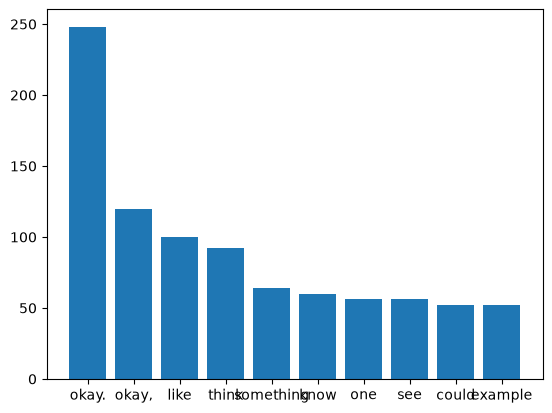

In [80]:

plt.bar(frecuencias_palabras_ordenado.keys(), frecuencias_palabras_ordenado.values())
plt.show()